In [1]:
import xarray as xr
data_path="/home/onyxia/gen-ai-fwi/data/"
ds = xr.open_dataset("/home/onyxia/gen-ai-fwi/data/eur11_rca4_CNRM-CERFACS-CNRM-CM5_historical_fwi-mean-jjas_20010101_20051231_v2.nc", engine="netcdf4")
print(ds)  # aperçu des variables, dimensions, coordonnées
print(ds.variables.keys())

<xarray.Dataset> Size: 10MB
Dimensions:        (time: 5, bnds: 2, rlat: 412, rlon: 424)
Coordinates:
  * time           (time) datetime64[ns] 40B 2000-11-01 ... 2004-11-01
  * rlat           (rlat) float64 3kB -23.38 -23.27 -23.16 ... 21.62 21.73 21.84
  * rlon           (rlon) float64 3kB -28.38 -28.27 -28.16 ... 17.94 18.05 18.16
    lon            (rlat, rlon) float64 1MB ...
    lat            (rlat, rlon) float64 1MB ...
Dimensions without coordinates: bnds
Data variables:
    rotated_pole   |S1 1B ...
    time_bnds      (time, bnds) datetime64[ns] 80B ...
    fwi-mean-jjas  (time, rlat, rlon) float64 7MB ...
Attributes: (12/13)
    creation_date:  2021-06-29-T17:37:26Z
    Frequency:      Annual
    institution:    National Observatory of Athens, URL: http://www.noa.gr
    contact:        cgiannak@noa.gr
    title:          fwi-mean-jjas
    references:     van Wagner, C. E., (1987). Development and structure of a...
    ...             ...
    history:        Version: 0.01
    L

In [2]:
df=ds['fwi-mean-jjas'].to_dataframe().reset_index()
print(df)

             time    rlat    rlon        lon        lat  fwi-mean-jjas
0      2000-11-01 -23.375 -28.375 -10.063880  21.987829      56.099262
1      2000-11-01 -23.375 -28.265  -9.963886  22.027838      58.940773
2      2000-11-01 -23.375 -28.155  -9.863804  22.067716      64.458809
3      2000-11-01 -23.375 -28.045  -9.763632  22.107462      64.989594
4      2000-11-01 -23.375 -27.935  -9.663371  22.147077      63.691593
...           ...     ...     ...        ...        ...            ...
873435 2004-11-01  21.835  17.715  64.138911  66.937210       5.155352
873436 2004-11-01  21.835  17.825  64.346672  66.875684       3.203302
873437 2004-11-01  21.835  17.935  64.553500  66.813945       2.019377
873438 2004-11-01  21.835  18.045  64.759400  66.751995       2.043339
873439 2004-11-01  21.835  18.155  64.964377  66.689837       3.625310

[873440 rows x 6 columns]


In [3]:
import geopandas as gpd
gdf = gpd.GeoDataFrame(
    df, geometry=gpd.points_from_xy(df.lon, df.lat), crs="EPSG:4326"
)
gdf


,time,rlat,rlon,lon,lat,fwi-mean-jjas,geometry
0,2000-11-01,-23.375,-28.375,-10.063880,21.987829,56.099262,POINT (-10.06388 21.98783)
1,2000-11-01,-23.375,-28.265,-9.963886,22.027838,58.940773,POINT (-9.96389 22.02784)
2,2000-11-01,-23.375,-28.155,-9.863804,22.067716,64.458809,POINT (-9.8638 22.06772)
3,2000-11-01,-23.375,-28.045,-9.763632,22.107462,64.989594,POINT (-9.76363 22.10746)
4,2000-11-01,-23.375,-27.935,-9.663371,22.147077,63.691593,POINT (-9.66337 22.14708)
...,...,...,...,...,...,...,...
873435,2004-11-01,21.835,17.715,64.138911,66.937210,5.155352,POINT (64.13891 66.93721)
873436,2004-11-01,21.835,17.825,64.346672,66.875684,3.203302,POINT (64.34667 66.87568)
873437,2004-11-01,21.835,17.935,64.553500,66.813945,2.019377,POINT (64.5535 66.81395)
873438,2004-11-01,21.835,18.045,64.759400,66.751995,2.043339,POINT (64.7594 66.752)


<Axes: >

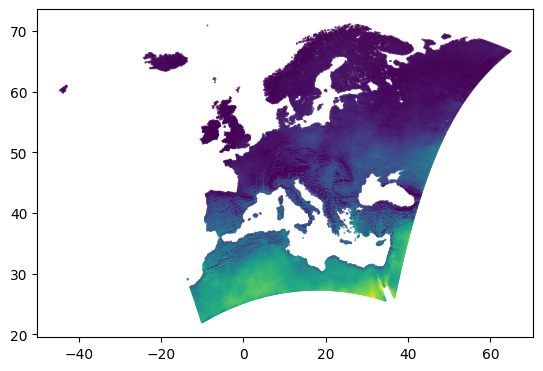

In [5]:
gdf_2000=gdf[gdf['time']=='2000-11-01']
gdf_2000.plot(column='fwi-mean-jjas',markersize=0.1)


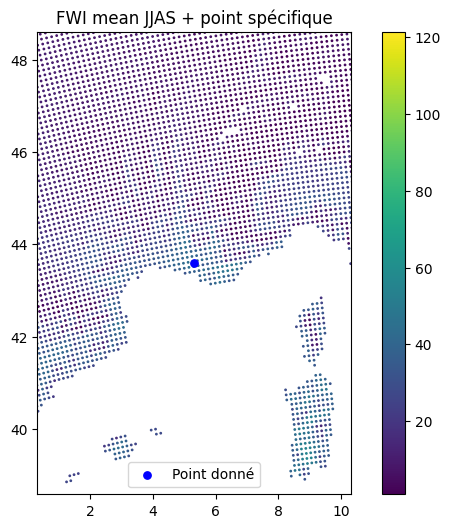

In [ ]:
import matplotlib.pyplot as plt


lat = 43.5911679
lon = 5.3102505

zoom=5



fig, ax = plt.subplots(figsize=(8,6))

# tes points
gdf_2000.plot(
    ax=ax,
    column='fwi-mean-jjas',
    markersize=1,
    legend=True
)

# point spécifique (ta coordonnée)
ax.scatter(lon, lat, color='blue', s=50, label="Point donné")

# zoom autour (optionnel)
ax.set_xlim(lon - zoom, lon + zoom)
ax.set_ylim(lat - zoom, lat + zoom)

ax.set_title("FWI mean JJAS + point spécifique")
ax.legend()

plt.show()


In [ ]:
import contextily as cx